<a href="https://colab.research.google.com/github/shaikmaheenn06/Restaurant-Rating-Prediction/blob/main/predict_restaurant_rating.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [89]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_squared_error, r2_score

In [90]:
df = pd.read_csv("/Dataset .csv")

In [91]:
df.drop("Rating color", axis=1, inplace=True)

In [92]:
df.columns


Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating text', 'Votes'],
      dtype='object')

In [93]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.8,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.5,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.4,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.9,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.8,Excellent,229


In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [95]:
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [96]:
df.isnull().sum()

,0
Restaurant ID,0
Restaurant Name,0
Country Code,0
City,0
Address,0
Locality,0
Locality Verbose,0
Longitude,0
Latitude,0
Cuisines,9


In [97]:
print(df.shape)
print(df.info())

(9551, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to 

In [98]:
df.isnull().sum()

,0
Restaurant ID,0
Restaurant Name,0
Country Code,0
City,0
Address,0
Locality,0
Locality Verbose,0
Longitude,0
Latitude,0
Cuisines,9


In [99]:

df["Cuisines"]= df["Cuisines"].fillna(df["Cuisines"].mode()[0])
for col in df.select_dtypes(include="object").columns:
  df[col] = df[col].fillna(df[col].mode()[0])
for col in df.select_dtypes(include=["int64","float64"]).columns:
  df[col] = df[col].fillna(df[col].median())
print(df.isnull().sum())

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                0
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating text             0
Votes                   0
dtype: int64


In [100]:
le = LabelEncoder()
for col in df.select_dtypes(include="object").columns:
  df[col] = le.fit_transform(df[col])
print(df.head)

<bound method NDFrame.head of       Restaurant ID  Restaurant Name  Country Code  City  Address  Locality  \
0           6317637             3748           162    73     8685       171   
1           6304287             3172           162    73     6055       593   
2           6300002             2896           162    75     4684       308   
3           6318506             4707           162    75     8690       862   
4           6314302             5523           162    75     8689       862   
...             ...              ...           ...   ...      ...       ...   
9546        5915730             4443           208   140     5926       517   
9547        5908749             1310           208   140     5962       552   
9548        5915807             3068           208   140     5966       554   
9549        5916112              512           208   140     5967       554   
9550        5927402             7240           208   140     4258       670   

      Locality Verbos

In [101]:
x = df.drop("Aggregate rating", axis=1)
y = df["Aggregate rating"]

In [102]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [103]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

In [104]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [105]:
print("Linear Regreation results")
print("mse",mse)
print("r2_score", r2)


Linear Regreation results
mse 1.278220791583402
r2_score 0.43841846017681174


In [106]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

In [107]:

mse_dt = mean_squared_error(y_test , dt_pred)
r2_dt = r2_score(y_test, dt_pred)
print("Decision Tree Results")
print("mse", mse_dt)
print("r2_score", r2_dt)


Decision Tree Results
mse 0.05736263736263735
r2_score 0.974797939111502


In [108]:

importance = pd.DataFrame({"Feature": x.columns, "Importance": dt.feature_importances_})
importance = importance.sort_values("Importance", ascending=False)
print(importance)


                 Feature  Importance
18                 Votes    0.898976
17           Rating text    0.089388
0          Restaurant ID    0.002359
7              Longitude    0.001393
4                Address    0.001382
1        Restaurant Name    0.001343
9               Cuisines    0.001253
8               Latitude    0.001106
10  Average Cost for two    0.001052
5               Locality    0.000592
6       Locality Verbose    0.000553
13   Has Online delivery    0.000263
3                   City    0.000186
12     Has Table booking    0.000076
16           Price range    0.000056
14     Is delivering now    0.000013
11              Currency    0.000006
2           Country Code    0.000004
15  Switch to order menu    0.000000


In [109]:
top10 = importance.head(10)

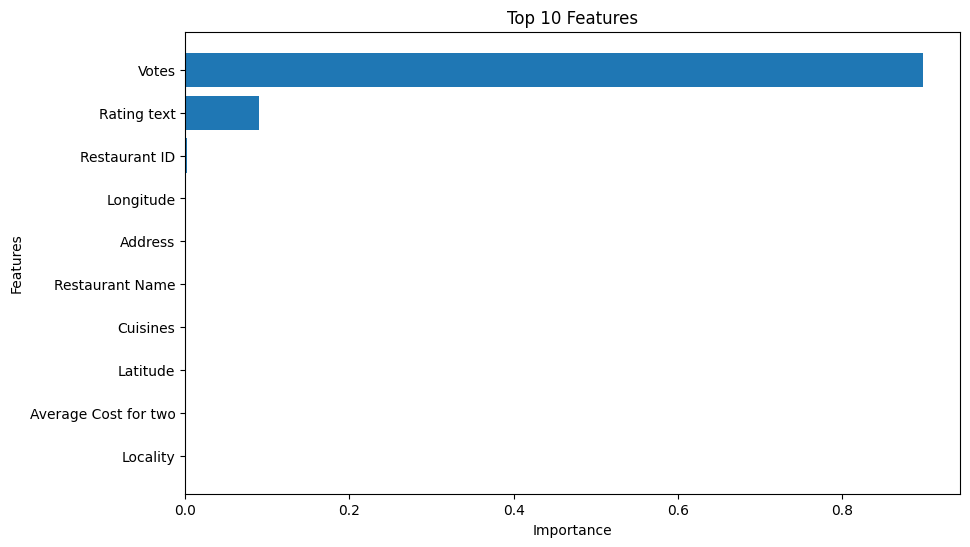

In [110]:
plt.figure(figsize=(10,6))
plt.barh(top10["Feature"], top10["Importance"])
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 10 Features")
plt.gca().invert_yaxis()
plt.show()

In [111]:
print("Linear Regression")
print("mse", mse)
print("r2_score", r2)


Linear Regression
mse 1.278220791583402
r2_score 0.43841846017681174


In [112]:
print("Decision Tree")
print("mse", mse_dt)
print("r2_score", r2_dt)

Decision Tree
mse 0.05736263736263735
r2_score 0.974797939111502
